In [1]:
import scanpy as sc
import treedata as td
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.insert(1, '/project/imoskowitz/yubin/SmoNull_NMPs_mesoderm_biased_analysis')
from src.III_celltype_annotation.run_celltype_annotation import run_find_markers, run_celltypist_annotation
from src.I_preprocessing.plot_preprocessing import plot_UMAP_custom


/project/imoskowitz/yubin/envs/Lineage_Tracing/lib/python3.10/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [2]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [102]:
data_dir = "output_data"
plot_dir = "output_plot"
base_path = "/project/imoskowitz/yubin/Lineage_Tree_Construction/"
output_path_data = base_path+data_dir+"/Celltypist/Predictions/Robin_Pijuan/E8_0/"
output_path_plot = base_path+plot_dir+"/Celltypist_annotation/Robin_Pijuan/E8_0/"

In [3]:
sys.path.append("/project/imoskowitz/shared/sequencing.processed/Smo_null_snRNAseq2025/3-Brain_system/Brain_system_analysis_python") 
from src.III_celltype_annotation.annotate_celltypist import (
    train_celltypist_model
)


In [17]:
robin_training_data = sc.read('/project/imoskowitz/kdreyer/lab_datasets/002_Cardio_mesodermal_atlas/Cardio-mesodermal_atlas_formatted_E85.h5ad')


In [18]:
robin_training_data

AnnData object with n_obs × n_vars = 3170 × 29205
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'S.Score', 'G2M.Score', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'Batch', 'Dataset', 'Old.groups', 'seurat_clusters', 'TimeStampMerged', 'Annotation', 'FHF_Pseudotime', 'JCF_Pseudotime', 'aSHF_Pseudotime', 'pSHF_Pseudotime'
    var: 'gene_symbol'
    layers: 'raw_counts'

In [19]:
from Moslin.celltypist_script.merging_atlas import merge_robin_pijuan_atlas


In [20]:
time = "E8.5" # Change this

In [21]:
def add_robin_celltype_annotation(robin_adata, pijuan_adata, robin_celltype_label, pijuan_celltype_label = "celltype_PijuanSala2019", merged_celltype_key = "merged_celltype_label"):
    '''

    Merging Robin's celltype and pijuan's celltype. Take all of Robin's celltype labeling, while keeping all cell's celltype that was not labeled by Robin as is. 
    Store the merged celltype in a new obs.
    MAKE SURE THAT INDEX FOR BOTH ADATA MATCH
    
    Parameters
    ----------
    robin_adata 
        The adata containing the new celltype labels for some cells 

    pijuan_adata 
        The adata containing the original celltype label from Pijuan

    timepoint
        The time point that will be merged and returned

    robin_celltype_label
        The obs name for robin's celltype label

    pijuan_celltype_label
        The obs name for Pijuan's original celltype labels

    merged_celltype_key
        The obs name that will store the merged celltype labeling
        
    Return
    ------
    Merged_adata
        The merged adata containing the merged celltype labeling. Default key: merged_celltype_label
    
    '''
    if robin_adata.obs.index.isin(pijuan_adata.obs.index).all() == False:
        raise Exception("Index values don't match. Make sure you set the cell index for both dataset")

    pijuan_adata.obs[merged_celltype_key] = robin_adata.obs[robin_celltype_label].combine_first(pijuan_adata.obs[pijuan_celltype_label])
    return pijuan_adata

In [22]:
def subset_robin_adata_to_timepoint_and_pijuan(adata, time, time_label="TimeStampMerged"):
    adata = adata[adata.obs[time_label] == time]
    adata = adata[adata.obs['Dataset'] == "Pijuan.2019"]
    return adata

#### Loading in Training data for the time point  of interest


In [23]:
robin_training_data

AnnData object with n_obs × n_vars = 3170 × 29205
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'S.Score', 'G2M.Score', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'Batch', 'Dataset', 'Old.groups', 'seurat_clusters', 'TimeStampMerged', 'Annotation', 'FHF_Pseudotime', 'JCF_Pseudotime', 'aSHF_Pseudotime', 'pSHF_Pseudotime'
    var: 'gene_symbol'
    layers: 'raw_counts'

In [26]:
# Subsetting to time point and cells that came from Pijuan
robin_training_data = subset_robin_adata_to_timepoint_and_pijuan(robin_training_data, time)

In [27]:
robin_training_data.obs["Annotation"].unique()

['pSHF/Pharyngeal mesoderm', 'CMs', 'JCF/Mesenchyme', 'ExE mesoderm', 'Differentiating CMs', ..., 'Mixed mesoderm', 'aSHF/Pharyngeal mesoderm', 'Nascent mesoderm', 'Primitive streak', 'Paraxial/Pharyngeal mesoderm']
Length: 11
Categories (11, object): ['CMs', 'Differentiating CMs', 'ExE mesoderm', 'JCF/Mesenchyme', ..., 'Paraxial/Pharyngeal mesoderm', 'Primitive streak', 'aSHF/Pharyngeal mesoderm', 'pSHF/Pharyngeal mesoderm']

Mouse gastr data for background cells (ie not cardiac related) for annotating whole embryo

In [43]:
mouse_gastr_adata = sc.read("/project/imoskowitz/kdreyer/celltypist_models/source_data/gastrulation_extended_E75_E775_E80_E825_E85_E875.h5ad")

Subsetting to time point

In [44]:
mouse_gastr_adata.obs['celltype_PijuanSala2019'].unique()

['ExE endoderm', 'Rostral neurectoderm', 'Blood progenitors 2', 'ExE ectoderm', 'Mixed mesoderm', ..., 'Erythroid2', 'NMP', 'Erythroid3', 'Neural crest', 'New cells']
Length: 38
Categories (38, object): ['Allantois', 'Anterior Primitive Streak', 'Blood progenitors 1', 'Blood progenitors 2', ..., 'Somitic mesoderm', 'Spinal cord', 'Surface ectoderm', 'Visceral endoderm']

In [45]:
mouse_gastr_subset = mouse_gastr_adata[mouse_gastr_adata.obs['stage'] == time]


In [47]:
mouse_gastr_subset = mouse_gastr_subset[mouse_gastr_subset.obs['celltype_PijuanSala2019'] != "New cells"]

In [ ]:
mouse_gastr_subset.obs['celltype_PijuanSala2019'] # 16k compared to 50k from before

30844                     Neural crest
30845                        Allantois
30846                       Erythroid3
30847     Forebrain/Midbrain/Hindbrain
30848                 Somitic mesoderm
                      ...             
116307                      Erythroid3
116308                      Erythroid3
116309                Somitic mesoderm
116310                      Erythroid3
116311    Forebrain/Midbrain/Hindbrain
Name: celltype_PijuanSala2019, Length: 16909, dtype: category
Categories (29, object): ['Allantois', 'Blood progenitors 1', 'Blood progenitors 2', 'Cardiomyocytes', ..., 'Somitic mesoderm', 'Spinal cord', 'Surface ectoderm', 'Visceral endoderm']

In [51]:
# Setting index to match that of Robins
mouse_gastr_subset.obs.set_index('cell', inplace=True)

#### Merging the two datasets, replacing cardiac labels in mouse gastr with robin's label

In [52]:
mouse_gastr_subset.X.max()

np.float64(5059.0)

In [53]:
merged_adata = add_robin_celltype_annotation(robin_training_data, mouse_gastr_subset, 'Annotation')

In [54]:
merged_adata.layers["raw_count"] = merged_adata.X

In [55]:
merged_adata.obs

,sample,embryo_version,stage,somite_count,anatomy,S_score,G2M_score,phase,louvain,leiden,celltype_PijuanSala2019,celltype_extended_atlas,n_genes,merged_celltype_label
cell,,,,,,,,,,,,,,
cell_36865,17,Original,E8.5,Pooled,Pooled,0.288704,0.516065,G2M,11,22,Neural crest,Migratory neural crest,3846,Neural crest
cell_36866,17,Original,E8.5,Pooled,Pooled,0.166138,0.794477,G2M,2,36,Allantois,Mesenchyme,4219,Allantois
cell_36867,17,Original,E8.5,Pooled,Pooled,0.377787,0.218232,S,6,11,Erythroid3,Erythroid,2305,Erythroid3
cell_36869,17,Original,E8.5,Pooled,Pooled,0.398000,0.229690,S,3,8,Forebrain/Midbrain/Hindbrain,Dorsal spinal cord progenitors,3589,Forebrain/Midbrain/Hindbrain
cell_36870,17,Original,E8.5,Pooled,Pooled,0.285141,0.563423,G2M,4,25,Somitic mesoderm,Caudal mesoderm,3621,Somitic mesoderm
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cell_139326,37,Original,E8.5,Pooled,Pooled,0.427993,0.411064,S,6,9,Erythroid3,Erythroid,3593,Erythroid3
cell_139327,37,Original,E8.5,Pooled,Pooled,0.365302,0.152054,S,6,48,Erythroid3,Erythroid,3006,Erythroid3
cell_139329,37,Original,E8.5,Pooled,Pooled,0.222692,0.694676,G2M,11,21,Somitic mesoderm,Somitic mesoderm,3950,Somitic mesoderm


# Training Model

In [ ]:
output_path_model = "/project/imoskowitz/yubin/Lineage_Tree_Construction/output_data/Celltypist/Models"
celltype_label = "merged_celltype_label"

# Name and file location of the reference adata
# atlas_subset_fname = f"Cardio-mesodermal_atlas_formatted_E85.h5ad"
# atlas_subset = sc.read_h5ad(
#     "/project/imoskowitz/kdreyer/lab_datasets/002_Cardio_mesodermal_atlas/Cardio-mesodermal_atlas_formatted_E85.h5ad"
# )
merged_adata.X = merged_adata.layers["raw_count"]
model, model_fname = train_celltypist_model(
    adata_atlas=merged_adata, adata_atlas_fname="Robin_Pijuan_annotation_"+time.replace(".","_"),
    celltype_label=celltype_label, output_path_model=output_path_model,
    top_genes=1000
)

print(model_fname)

🍳 Preparing data before training
✂️ 11 non-expressed genes are filtered out
🔬 Input data has 58072 cells and 20007 genes
⚖️ Scaling input data
🏋️ Training data using SGD logistic regression
🔎 Selecting features
🧬 10687 features are selected
🏋️ Starting the second round of training
🏋️ Training data using logistic regression


# Prediction

In [123]:
tdata = td.read_h5td("/project/imoskowitz/yubin/Lineage_Tree_Construction/output_data/Processed_data/E8_5.h5td")


In [124]:
tdata

TreeData object with n_obs × n_vars = 89230 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_low_score', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l025', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l05', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l10', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l20'
    var: 'gene_ids', 'mito', 'chromosome'
    uns: 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_colors', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l025_colors', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l05_colors', 

In [126]:
tdata.X.max()

np.float32(6747.0)

In [ ]:
# This for E8.0
tdata.X = tdata.layers["Raw_count"]
tdata.layers['raw_counts'] = tdata.X
del tdata.layers["Raw_count"]


SyntaxError: invalid syntax (3881485532.py, line 3)

In [128]:
output_path_model = "/project/imoskowitz/yubin/Lineage_Tree_Construction/output_data/Celltypist/Models/Robin_Pijuan/E8_5/"
model_fname = "Robin_Pijuan_annotation_E8_5_model_top1000.pkl"

In [129]:
### set clusters to use to get mode cell type per cluster
### make sure these match clustering resolutions/names in the adata
cluster_col_list = ["leiden_0.25", "leiden_0.5", "leiden_1.0", "leiden_2.0"]
clustering_name_list = ["l025", "l05", "l10", "l20"]

Note that For E8.5 the cell_type is instead called "Annotation"

In [131]:
data_dir = "output_data"
plot_dir = "output_plot"
base_path = "/project/imoskowitz/yubin/Lineage_Tree_Construction/"
output_path_data = base_path+data_dir+"/Celltypist/Predictions/Robin_Pijuan/E8_5/"
output_path_plot = base_path+plot_dir+"/Celltypist_annotation/Robin_Pijuan/E8_5/"

In [145]:
tdata.X = tdata.layers["raw_counts"]
adata_anno, top_celltypes_dict = run_celltypist_annotation(
    adata=tdata, adata_atlas_path=None, time_pt=None, celltype_label= "merged_celltype_label", umap_coords_obsm="X_umap",
    output_path_data=output_path_data, output_path_model=output_path_model, 
    output_path_plot=output_path_plot, cluster_col_list=cluster_col_list,
    clustering_name_list=clustering_name_list, model_fname=model_fname,
    majority_voting=True
)

🔬 Input data has 89230 cells and 48004 genes
🔗 Matching reference genes in the model
🧬 11993 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 20
🗳️ Majority voting the predictions
✅ Majority voting done!
... storing 'tree' as categorical
... storing 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l025' as categorical
... storing 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l05' as categorical
... storing 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l10' as categorical
... storing 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l20' as categorical


In [133]:
adata_anno

TreeData object with n_obs × n_vars = 89230 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_low_score', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l025', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l05', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l10', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l20', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label', 'Robin_Pijuan_annotation_E8_5_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l025', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l05', 'Robin_Pijuan_annotation_E8_5_model_top100

#### Plotting results

ValueError: Cannot specify `ax` when plotting multiple panels (each for a given value of 'color').

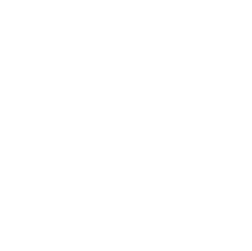

In [ ]:
plot_UMAP_custom(adata=adata_anno,
        umap_coords_obsm="X_umap",
        color_by="Robin_Pijuan_annotation_E8_5_model_top1000_low_score",
        palette = "tab20",
        fig_title="Individual cell celltypist individual confidence",
        output_path_plot=output_path_plot, 
        output_fname="umap_celltypist_individual_confidence.svg",
)

#### Adding predicted celltype back to original tdata

In [137]:
tdata

TreeData object with n_obs × n_vars = 89230 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_low_score', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l025', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l05', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l10', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l20', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label', 'Robin_Pijuan_annotation_E8_5_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l025', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l05', 'Robin_Pijuan_annotation_E8_5_model_top100

In [146]:
adata_anno

TreeData object with n_obs × n_vars = 89230 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label', 'Robin_Pijuan_annotation_E8_5_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l025', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l05', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l10', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l20'
    var: 'gene_ids', 'mito', 'chromosome'
    uns: 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_colors', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l025_colors', 'Card

In [140]:
cols_to_delete = [
    'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l025',
    'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l05',
    'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l10',
    'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l20',
    'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label', 
    'Robin_Pijuan_annotation_E8_5_model_top1000_low_score', 
    'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l025', 
    'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l05', 
    'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l10', 
    'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l20'
]

tdata.obs.drop(columns=cols_to_delete, inplace=True)

In [147]:
tdata

TreeData object with n_obs × n_vars = 89230 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label', 'Robin_Pijuan_annotation_E8_5_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l025', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l05', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l10', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l20'
    var: 'gene_ids', 'mito', 'chromosome'
    uns: 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_colors', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l025_colors', 'Card

In [143]:
tdata.obs["Robin_Pijuan_celltypist_annotation"] = adata_anno.obs["Robin_Pijuan_annotation_E8_5_model_top1000_mv_label"]
tdata.uns["Robin_Pijuan_celltypist_annotation_colors"] = adata_anno.uns['Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_colors']

KeyError: 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label'

In [148]:
tdata.write("/project/imoskowitz/yubin/Lineage_Tree_Construction/output_data/Processed_data/E8_5.h5td")

#### Retrieving Accidentally deleted E8.5 (oops)

In [58]:
converted_adata = td.TreeData(adata) # Taking the umap from this prediction adata, appending the treedata information to remake the original processed tdata

In [ ]:
tdata = td.read_h5td("/project/imoskowitz/yubin/Lineage_Tree_Construction/output_data/Processed_data/E8_5.h5td")

In [ ]:
converted_adata

TreeData object with n_obs × n_vars = 89230 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_low_score', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l025', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l05', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l10', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l20'
    var: 'gene_ids', 'mito', 'chromosome'
    uns: 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_colors', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l025_colors', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_mode_l05_colors', 

In [25]:
for tree in list(tdata.obst):
    converted_adata.obst[tree] = tdata.obst[tree]

In [ ]:
# converted_adata.write('/project/imoskowitz/yubin/Lineage_Tree_Construction/output_data/E8_5.h5td')

... storing 'tree' as categorical
